In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [ ]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
import ydata_profiling

/tmp/ipykernel_3511/1121382538.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, explorative=True)
profile.to_file("Telco_churn_EDA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 22.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Checking missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
#Making a copy of original dataset

df_clean = df.copy()

Handling duplicate values

In [ ]:
#Checking duplicate values

df_clean.duplicated().sum()

np.int64(0)

Dealing with blank values

In [ ]:
# Retrieve rows where TotalCharges contains only whitespace
blank_values = df_clean[
    df_clean['TotalCharges'].astype(str).str.strip() == ''
]

print(blank_values)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [ ]:
import re

In [ ]:
# Convert blank or whitespace-only values to NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [ ]:
# Since all missing TotalCharges belong to customers with tenure = 0,
# replace them with 0 because they have no accumulated billing history
df_clean.loc[
    (df_clean["tenure"] == 0) &
    (df_clean["TotalCharges"].isna()),
    "TotalCharges"
] = 0

Changing datatypes

In [ ]:
# -----------------------------------
# 1. Convert TotalCharges to numeric
# -----------------------------------

# First, convert the column from object to numeric.
# errors='coerce' ensures that any invalid values are converted to NaN.
df_clean['TotalCharges'] = pd.to_numeric(
    df_clean['TotalCharges'],
    errors='coerce'
)


In [ ]:
# -----------------------------------
# 2. Convert SeniorCitizen to boolean
# -----------------------------------

# 0 becomes False and 1 becomes True
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype(bool)

# Optional: check the new datatype and values
print("SeniorCitizen datatype:", df_clean['SeniorCitizen'].dtype)
print(df_clean['SeniorCitizen'].value_counts())

SeniorCitizen datatype: bool
SeniorCitizen
False    5901
True     1142
Name: count, dtype: int64


In [ ]:
# check the new datatype and values
print(df_clean['SeniorCitizen'].dtype)
print(df_clean['TotalCharges'].dtype)


bool
float64


Managing inconsistent formatting

In [ ]:
# Get all columns with object data type
object_cols = df_clean.select_dtypes(include="object").columns

# Remove leading and trailing spaces from all object columns
df_clean[object_cols] = df_clean[object_cols].apply(lambda col: col.str.strip())

# Display the object columns that were cleaned
print("Cleaned object columns:")
print(object_cols.tolist())

Cleaned object columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
# Get all object columns
object_cols = df_clean.select_dtypes(include="object").columns

# Remove leading/trailing spaces and reduce multiple internal spaces to one
df_clean[object_cols] = df_clean[object_cols].apply(
    lambda col: col.str.replace(r"\s+", " ", regex=True).str.strip()
)

In [ ]:
object_cols.unique()

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [ ]:
# Display unique values for each object column
for col in object_cols:
    print(f"\n{'=' * 50}")
    print(f"Column: {col}")
    print(f"Unique values ({df_clean[col].nunique()}):")
    print(df_clean[col].unique())


Column: customerID
Unique values (7043):
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Column: gender
Unique values (2):
['Female' 'Male']

Column: Partner
Unique values (2):
['Yes' 'No']

Column: Dependents
Unique values (2):
['No' 'Yes']

Column: PhoneService
Unique values (2):
['No' 'Yes']

Column: MultipleLines
Unique values (3):
['No phone service' 'No' 'Yes']

Column: InternetService
Unique values (3):
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
Unique values (3):
['No' 'Yes' 'No internet service']

Column: OnlineBackup
Unique values (3):
['Yes' 'No' 'No internet service']

Column: DeviceProtection
Unique values (3):
['No' 'Yes' 'No internet service']

Column: TechSupport
Unique values (3):
['No' 'Yes' 'No internet service']

Column: StreamingTV
Unique values (3):
['No' 'Yes' 'No internet service']

Column: StreamingMovies
Unique values (3):
['No' 'Yes' 'No internet service']

Column: Contract
Unique values (3):
['Month-to-month' 'O

In [ ]:
df_clean.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Check impossable and suspicious numeric values

In [ ]:
df_clean[df_clean['TotalCharges']==0]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,False,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,False,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,False,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [ ]:
# Case 1: Customers with tenure = 0 but TotalCharges > 0
case1 = df_clean[
    (df_clean["tenure"] == 0) &
    (df_clean["TotalCharges"] > 0)
]

# Case 2: Customers with tenure > 0 but TotalCharges = 0
case2 = df_clean[
    (df_clean["tenure"] > 0) &
    (df_clean["TotalCharges"] == 0)
]

print("Tenure = 0 but TotalCharges > 0:", len(case1))
print("Tenure > 0 but TotalCharges = 0:", len(case2))

Tenure = 0 but TotalCharges > 0: 0
Tenure > 0 but TotalCharges = 0: 0


In [ ]:
# Find rows where tenure is negative
negative_tenure = df_clean[df_clean["tenure"] < 0]

print("Rows with negative tenure:")
print(negative_tenure)
print("\nCount:", len(negative_tenure))

Rows with negative tenure:
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]

Count: 0


In [ ]:
# List of charge-related columns
charge_cols = [
    "MonthlyCharges",
    "TotalCharges"
]

# Find rows where any charge column contains a negative value
negative_charges = df_clean[
    (df_clean[charge_cols] < 0).any(axis=1)
]

print("Rows with negative charges:")
print(negative_charges)
print("\nCount:", len(negative_charges))

Rows with negative charges:
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]

Count: 0


In [ ]:
# Find rows where tenure or any charge-related column is negative
negative_values = df_clean[
    (df_clean["tenure"] < 0) |
    (df_clean[charge_cols] < 0).any(axis=1)
]

print("Rows with negative tenure or charges:")
print(negative_values)

print("\nTotal suspicious rows:", len(negative_values))

In [ ]:
# Create expected total charges based on current monthly charges
df_clean["expected_total"] = (
    df_clean["tenure"] * df_clean["MonthlyCharges"]
)

# Calculate the difference
df_clean["charge_difference"] = (
    df_clean["TotalCharges"] - df_clean["expected_total"]
)

# Calculate percentage difference
df_clean["percentage_difference"] = np.where(
    df_clean["expected_total"] != 0,
    (df_clean["charge_difference"].abs() / df_clean["expected_total"]) * 100,
    np.nan
)

# Display the comparison
df_clean[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "expected_total",
        "charge_difference",
        "percentage_difference"
    ]
].head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,expected_total,charge_difference,percentage_difference
0,7590-VHVEG,1,29.85,29.85,29.85,0.00,0.000000
1,5575-GNVDE,34,56.95,1889.50,1936.30,-46.80,2.416981
2,3668-QPYBK,2,53.85,108.15,107.70,0.45,0.417827
3,7795-CFOCW,45,42.30,1840.75,1903.50,-62.75,3.296559
4,9237-HQITU,2,70.70,151.65,141.40,10.25,7.248939
5,9305-CDSKC,8,99.65,820.50,797.20,23.30,2.922730
6,1452-KIOVK,22,89.10,1949.40,1960.20,-10.80,0.550964
7,6713-OKOMC,10,29.75,301.90,297.50,4.40,1.478992
8,7892-POOKP,28,104.80,3046.05,2934.40,111.65,3.804866
9,6388-TABGU,62,56.15,3487.95,3481.30,6.65,0.191021


In [ ]:
# Flag rows where TotalCharges differs from the estimated value by more than 20%
suspicious_charges = df_clean[
    df_clean["percentage_difference"] > 20
]

print("Number of potentially suspicious rows:", len(suspicious_charges))

display(
    suspicious_charges[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "expected_total",
            "charge_difference",
            "percentage_difference"
        ]
    ].sort_values("percentage_difference", ascending=False)
)

Number of potentially suspicious rows: 59


,customerID,tenure,MonthlyCharges,TotalCharges,expected_total,charge_difference,percentage_difference
5595,2308-STERM,2,19.40,61.05,38.80,22.25,57.345361
869,0323-XWWTN,3,26.40,121.25,79.20,42.05,53.093434
5673,6260-XLACS,4,19.70,117.80,78.80,39.00,49.492386
4689,2832-SCUCO,2,19.90,57.40,39.80,17.60,44.221106
4634,9426-SXNHE,2,18.75,53.15,37.50,15.65,41.733333
3945,3815-SLMEF,3,34.25,139.35,102.75,36.60,35.620438
6828,2005-DWQZJ,8,19.05,201.70,152.40,49.30,32.349081
6619,2791-SFVEW,9,20.15,238.15,181.35,56.80,31.320651
2950,3345-JHUEO,4,20.20,55.70,80.80,-25.10,31.064356
4203,4291-YZODP,7,20.05,96.80,140.35,-43.55,31.029569


In [ ]:
# Display suspicious rows where TotalCharges is more than 20%
# higher than tenure × current MonthlyCharges

suspicious_charges[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "expected_total",
        "charge_difference",
        "percentage_difference"
    ]
].sort_values("percentage_difference", ascending=False)

,customerID,tenure,MonthlyCharges,TotalCharges,expected_total,charge_difference,percentage_difference
5595,2308-STERM,2,19.40,61.05,38.80,22.25,57.345361
869,0323-XWWTN,3,26.40,121.25,79.20,42.05,53.093434
5673,6260-XLACS,4,19.70,117.80,78.80,39.00,49.492386
4689,2832-SCUCO,2,19.90,57.40,39.80,17.60,44.221106
4634,9426-SXNHE,2,18.75,53.15,37.50,15.65,41.733333
3945,3815-SLMEF,3,34.25,139.35,102.75,36.60,35.620438
6828,2005-DWQZJ,8,19.05,201.70,152.40,49.30,32.349081
6619,2791-SFVEW,9,20.15,238.15,181.35,56.80,31.320651
2950,3345-JHUEO,4,20.20,55.70,80.80,-25.10,31.064356
4203,4291-YZODP,7,20.05,96.80,140.35,-43.55,31.029569


In [ ]:
# Calculate the average monthly amount historically paid by each customer
df_clean["average_historical_monthly_charge"] = np.where(
    df_clean["tenure"] > 0,
    df_clean["TotalCharges"] / df_clean["tenure"],
    np.nan
)

# Compare historical average with current MonthlyCharges
df_clean["monthly_charge_change"] = (
    df_clean["MonthlyCharges"] -
    df_clean["average_historical_monthly_charge"]
)

# Display suspicious rows
suspicious_charges = df_clean[
    df_clean["percentage_difference"] > 20
]

display(
    suspicious_charges[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "average_historical_monthly_charge",
            "monthly_charge_change",
            "percentage_difference"
        ]
    ].sort_values("percentage_difference", ascending=False)
)

,customerID,tenure,MonthlyCharges,TotalCharges,average_historical_monthly_charge,monthly_charge_change,percentage_difference
5595,2308-STERM,2,19.40,61.05,30.525000,-11.125000,57.345361
869,0323-XWWTN,3,26.40,121.25,40.416667,-14.016667,53.093434
5673,6260-XLACS,4,19.70,117.80,29.450000,-9.750000,49.492386
4689,2832-SCUCO,2,19.90,57.40,28.700000,-8.800000,44.221106
4634,9426-SXNHE,2,18.75,53.15,26.575000,-7.825000,41.733333
3945,3815-SLMEF,3,34.25,139.35,46.450000,-12.200000,35.620438
6828,2005-DWQZJ,8,19.05,201.70,25.212500,-6.162500,32.349081
6619,2791-SFVEW,9,20.15,238.15,26.461111,-6.311111,31.320651
2950,3345-JHUEO,4,20.20,55.70,13.925000,6.275000,31.064356
4203,4291-YZODP,7,20.05,96.80,13.828571,6.221429,31.029569


Detecting outliers

In [ ]:
# Columns to check for outliers
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Store outlier results
outlier_summary = []

for col in numeric_cols:

    # Calculate Q1, Q3, and IQR
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    # Save results
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(df_clean) * 100, 2)
    })

    print(f"\n{'=' * 50}")
    print(f"Column: {col}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Outliers found: {len(outliers)}")
    print(outliers[[col]].sort_values(col))

# Create a summary table
outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)


Column: tenure
Lower bound: -60.0
Upper bound: 124.0
Outliers found: 0
Empty DataFrame
Columns: [tenure]
Index: []

Column: MonthlyCharges
Lower bound: -46.02499999999999
Upper bound: 171.375
Outliers found: 0
Empty DataFrame
Columns: [MonthlyCharges]
Index: []

Column: TotalCharges
Lower bound: -4683.525
Upper bound: 8868.675
Outliers found: 0
Empty DataFrame
Columns: [TotalCharges]
Index: []


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0


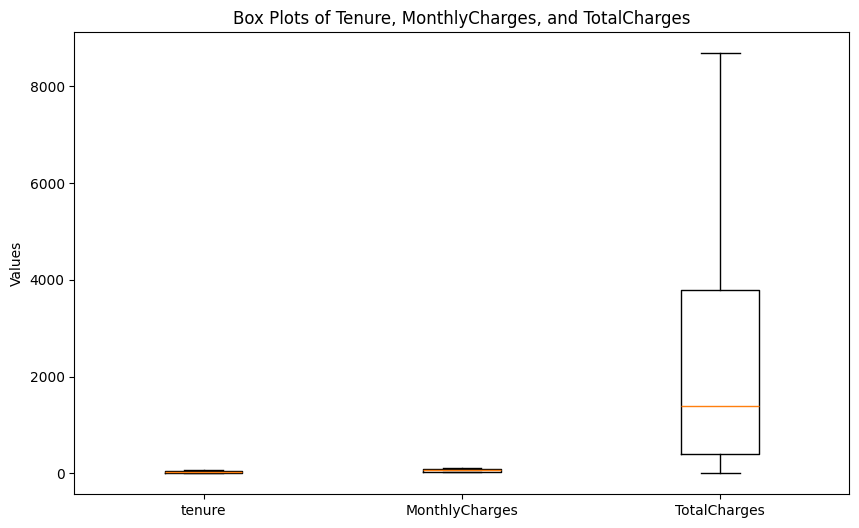

In [ ]:
import matplotlib.pyplot as plt

# Columns to visualize
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [df_clean[col].dropna() for col in numeric_cols],
    tick_labels=numeric_cols
)

plt.title("Box Plots of Tenure, MonthlyCharges, and TotalCharges")

plt.ylabel("Values")

plt.show()